# Notebook — Teste do módulo `remove_restore.py`

Este notebook testa o módulo:

```python
geodesy/remove_restore.py
```

Serão testadas as funções:

- `remove_global_model`
- `restore_global_model`
- `remove_terrain_effect`
- `restore_terrain_effect`
- `remove_restore_workflow`

Os exemplos usam um campo sintético observado, um modelo global de longo comprimento de onda, um efeito topográfico e um residual local.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")
    print("Coloque este notebook no mesmo diretório da pasta geodesy/.")

import geodesy
from geodesy import remove_restore

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Campo sintético 1D


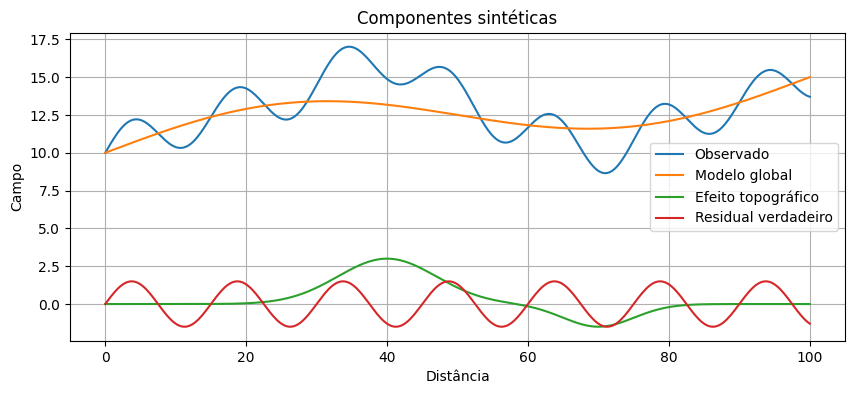

In [2]:
# ============================================================
# 1. CAMPO SINTÉTICO 1D
# ============================================================

x = np.linspace(0, 100, 400)

global_model = 10 + 0.05*x + 2*np.sin(2*np.pi*x/100)
terrain_effect = 3*np.exp(-0.5*((x-40)/7)**2) - 1.5*np.exp(-0.5*((x-70)/5)**2)
local_residual_true = 1.5*np.sin(2*np.pi*x/15)

observed = global_model + terrain_effect + local_residual_true

plt.figure(figsize=(10, 4))
plt.plot(x, observed, label="Observado")
plt.plot(x, global_model, label="Modelo global")
plt.plot(x, terrain_effect, label="Efeito topográfico")
plt.plot(x, local_residual_true, label="Residual verdadeiro")
plt.xlabel("Distância")
plt.ylabel("Campo")
plt.title("Componentes sintéticas")
plt.legend()
plt.grid(True)
plt.show()


## 2. Remoção e restauração do modelo global


Erro máximo após remover e restaurar modelo global:
0.0


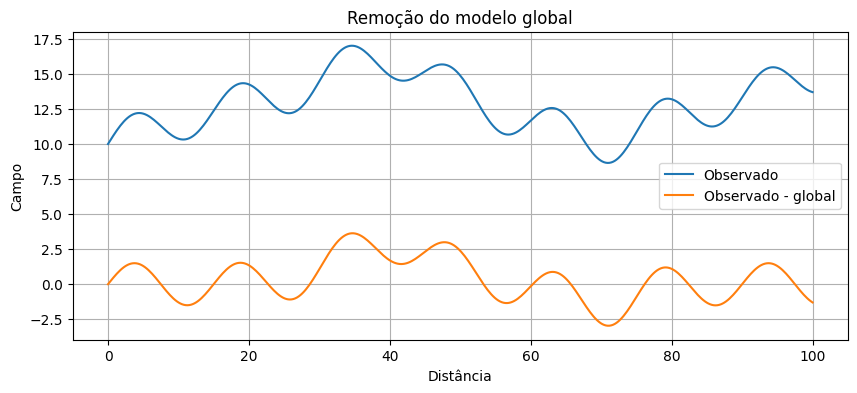

In [3]:
# ============================================================
# 2. REMOVE / RESTORE GLOBAL
# ============================================================

residual_without_global = remove_restore.remove_global_model(observed, global_model)
restored_global = remove_restore.restore_global_model(residual_without_global, global_model)

print("Erro máximo após remover e restaurar modelo global:")
print(np.max(np.abs(restored_global - observed)))

plt.figure(figsize=(10, 4))
plt.plot(x, observed, label="Observado")
plt.plot(x, residual_without_global, label="Observado - global")
plt.xlabel("Distância")
plt.ylabel("Campo")
plt.title("Remoção do modelo global")
plt.legend()
plt.grid(True)
plt.show()


## 3. Remoção e restauração do efeito topográfico


Erro máximo após remover e restaurar terreno:
1.7763568394002505e-15


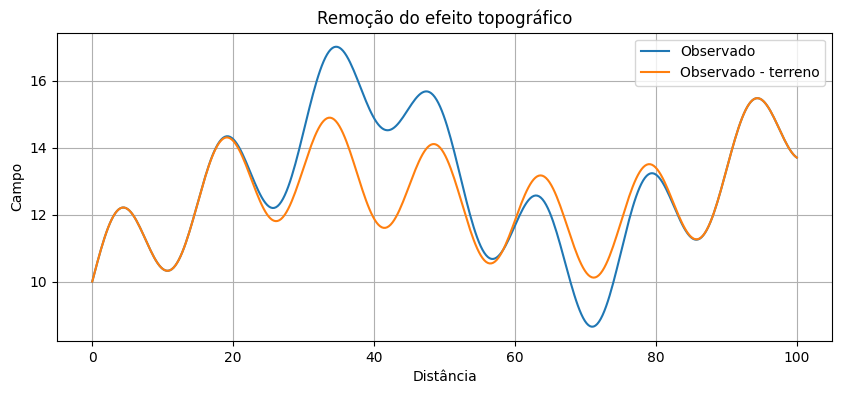

In [4]:
# ============================================================
# 3. REMOVE / RESTORE TERRENO
# ============================================================

residual_without_terrain = remove_restore.remove_terrain_effect(observed, terrain_effect)
restored_terrain = remove_restore.restore_terrain_effect(residual_without_terrain, terrain_effect)

print("Erro máximo após remover e restaurar terreno:")
print(np.max(np.abs(restored_terrain - observed)))

plt.figure(figsize=(10, 4))
plt.plot(x, observed, label="Observado")
plt.plot(x, residual_without_terrain, label="Observado - terreno")
plt.xlabel("Distância")
plt.ylabel("Campo")
plt.title("Remoção do efeito topográfico")
plt.legend()
plt.grid(True)
plt.show()


## 4. Fluxo remove-restore completo


Residual min/max: -1.4998953853064332 1.499988376025056
Modeled residual min/max: -1.551802874531656 1.4480808867998332
Final min/max: 8.599015060205382 16.958889173599218


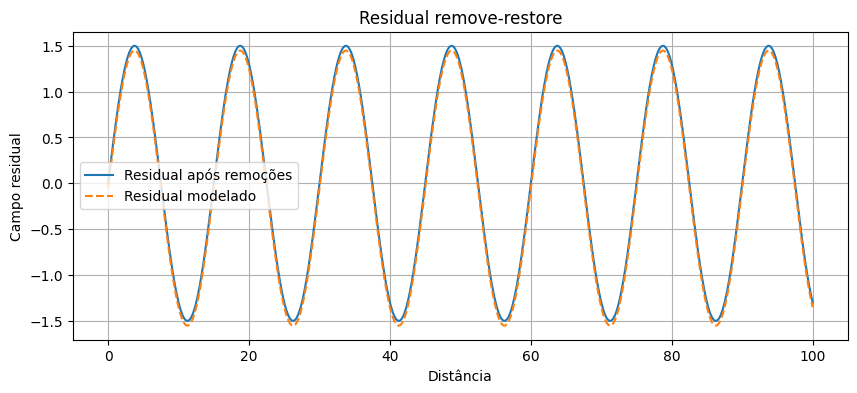

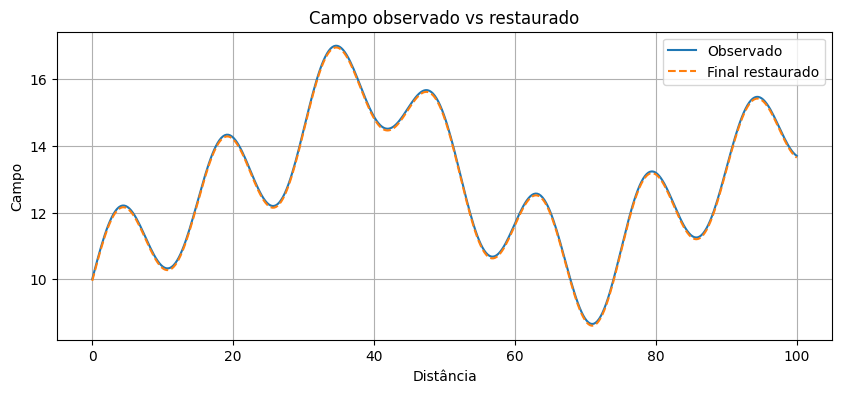

In [5]:
# ============================================================
# 4. WORKFLOW REMOVE-RESTORE
# ============================================================

def simple_modeling_function(residual):
    # Modelo didático: remove apenas a média do residual
    return residual - np.mean(residual)

final, residual, modeled_residual = remove_restore.remove_restore_workflow(
    observed,
    global_model=global_model,
    terrain_effect=terrain_effect,
    modeling_function=simple_modeling_function
)

print("Residual min/max:", np.min(residual), np.max(residual))
print("Modeled residual min/max:", np.min(modeled_residual), np.max(modeled_residual))
print("Final min/max:", np.min(final), np.max(final))

plt.figure(figsize=(10, 4))
plt.plot(x, residual, label="Residual após remoções")
plt.plot(x, modeled_residual, linestyle="--", label="Residual modelado")
plt.xlabel("Distância")
plt.ylabel("Campo residual")
plt.title("Residual remove-restore")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x, observed, label="Observado")
plt.plot(x, final, linestyle="--", label="Final restaurado")
plt.xlabel("Distância")
plt.ylabel("Campo")
plt.title("Campo observado vs restaurado")
plt.legend()
plt.grid(True)
plt.show()


## 5. Campo sintético 2D


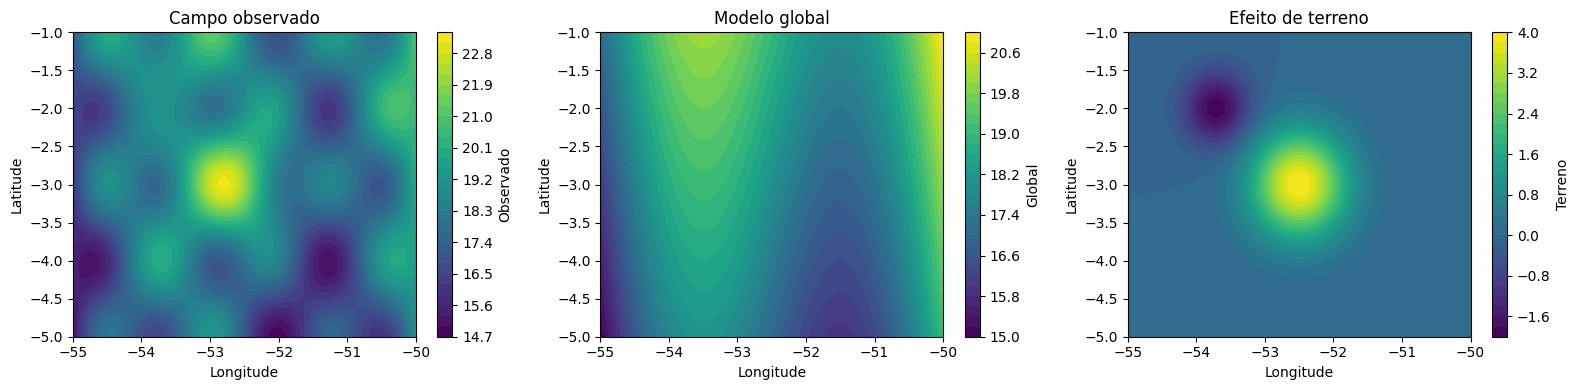

In [6]:
# ============================================================
# 5. CAMPO SINTÉTICO 2D
# ============================================================

lon = np.linspace(-55, -50, 120)
lat = np.linspace(-5, -1, 100)

LON, LAT = np.meshgrid(lon, lat)

GLOBAL = (
    15
    + 0.8*(LON + 55)
    + 0.5*(LAT + 5)
    + 2*np.sin((LON + 55)*2*np.pi/5)
)

TERRAIN = (
    4*np.exp(-((LON+52.5)**2 + (LAT+3.0)**2)/0.5)
    - 2*np.exp(-((LON+53.7)**2 + (LAT+2.0)**2)/0.25)
)

LOCAL = 1.5*np.sin((LON+55)*6*np.pi/5)*np.cos((LAT+5)*4*np.pi/4)

OBS = GLOBAL + TERRAIN + LOCAL

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
c1 = plt.contourf(LON, LAT, OBS, levels=30)
plt.colorbar(c1, label="Observado")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Campo observado")

plt.subplot(1, 3, 2)
c2 = plt.contourf(LON, LAT, GLOBAL, levels=30)
plt.colorbar(c2, label="Global")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Modelo global")

plt.subplot(1, 3, 3)
c3 = plt.contourf(LON, LAT, TERRAIN, levels=30)
plt.colorbar(c3, label="Terreno")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Efeito de terreno")

plt.tight_layout()
plt.show()


## 6. Remove-restore em 2D


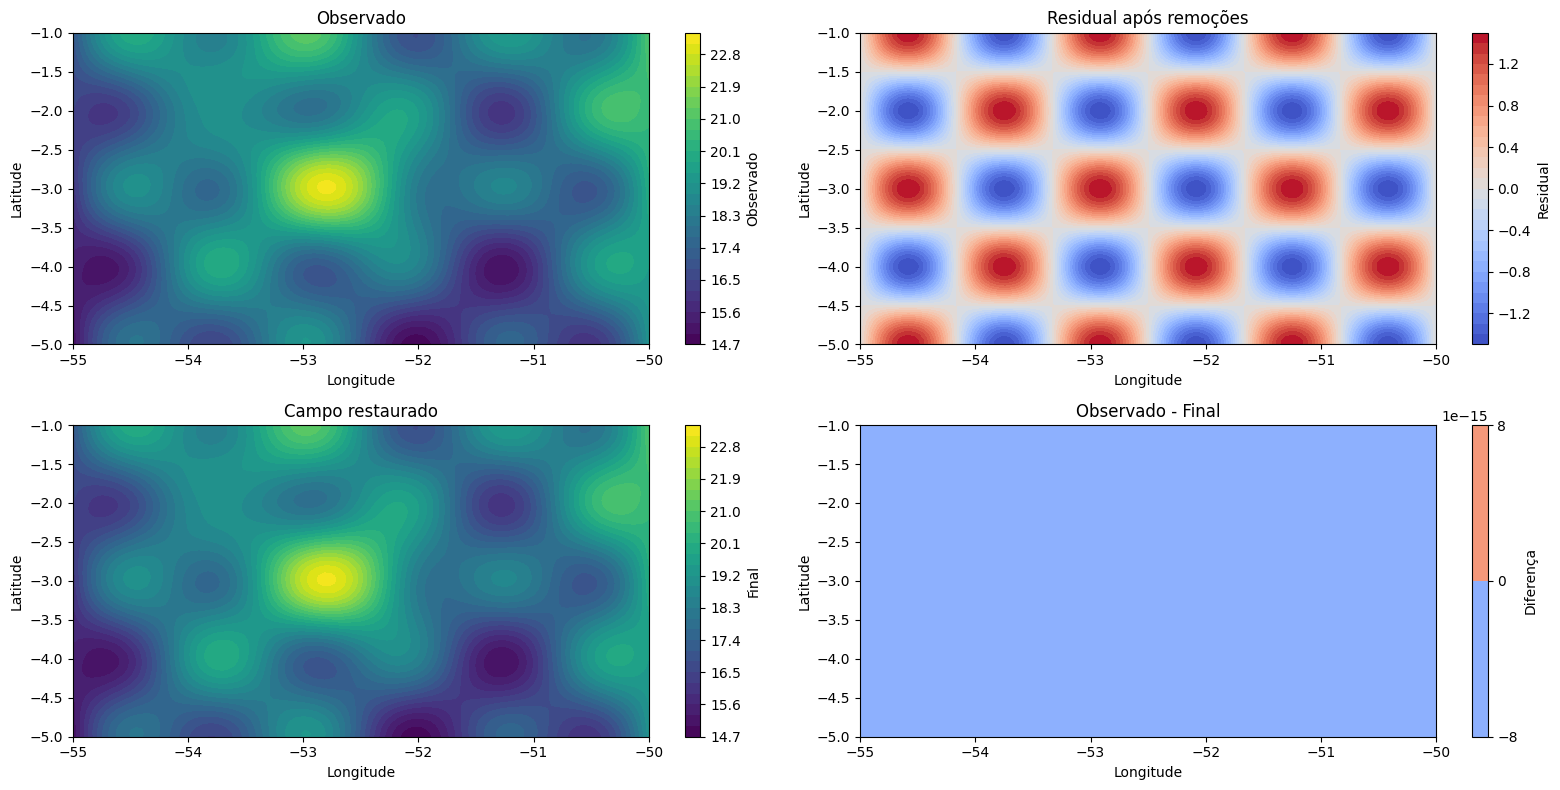

Erro médio: 0.0
RMSE: 0.0
Erro máximo: 0.0


In [8]:
# ============================================================
# 6. REMOVE-RESTORE EM MAPA 2D
# ============================================================

def residual_model_2d(residual):
    # Modelo didático: remove a média global do residual
    return residual - np.nanmean(residual)

FINAL, RESIDUAL, MODELED = remove_restore.remove_restore_workflow(
    OBS,
    global_model=GLOBAL,
    terrain_effect=TERRAIN,
    modeling_function=residual_model_2d
)

DIFF = OBS - FINAL

plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
c1 = plt.contourf(LON, LAT, OBS, levels=30)
plt.colorbar(c1, label="Observado")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Observado")

plt.subplot(2, 2, 2)
c2 = plt.contourf(LON, LAT, RESIDUAL, levels=30, cmap="coolwarm")
plt.colorbar(c2, label="Residual")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Residual após remoções")

plt.subplot(2, 2, 3)
c3 = plt.contourf(LON, LAT, FINAL, levels=30)
plt.colorbar(c3, label="Final")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Campo restaurado")

plt.subplot(2, 2, 4)
vmax = np.nanmax(np.abs(DIFF))
c4 = plt.contourf(LON, LAT, DIFF, levels=30, cmap="coolwarm")
plt.colorbar(c4, label="Diferença")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Observado - Final")

plt.tight_layout()
plt.show()

print("Erro médio:", np.nanmean(DIFF))
print("RMSE:", np.sqrt(np.nanmean(DIFF**2)))
print("Erro máximo:", np.nanmax(np.abs(DIFF)))


## 7. Comparação entre componentes


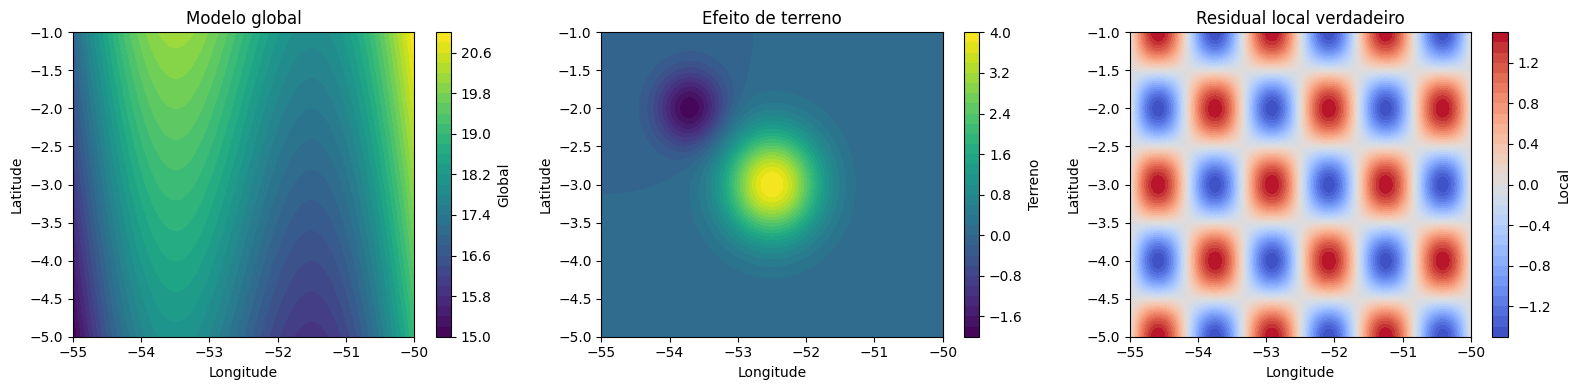

In [9]:
# ============================================================
# 7. COMPARAÇÃO ENTRE COMPONENTES
# ============================================================

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
c1 = plt.contourf(LON, LAT, GLOBAL, levels=30)
plt.colorbar(c1, label="Global")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Modelo global")

plt.subplot(1, 3, 2)
c2 = plt.contourf(LON, LAT, TERRAIN, levels=30)
plt.colorbar(c2, label="Terreno")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Efeito de terreno")

plt.subplot(1, 3, 3)
c3 = plt.contourf(LON, LAT, LOCAL, levels=30, cmap="coolwarm")
plt.colorbar(c3, label="Local")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Residual local verdadeiro")

plt.tight_layout()
plt.show()


## 8. Mapa global didático com Mollweide


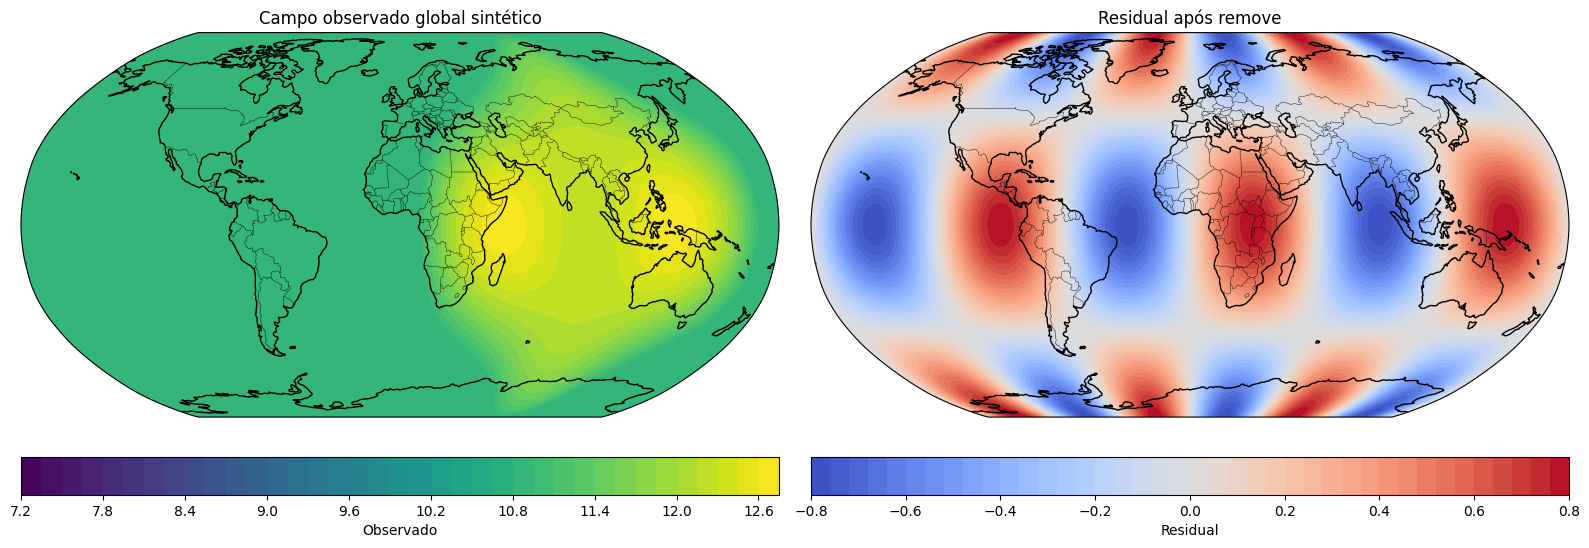

In [11]:
# ============================================================
# 8. MAPA GLOBAL DIDÁTICO COM CARTOPY / MOLLWEIDE
# ============================================================

import cartopy.crs as ccrs
import cartopy.feature as cfeature

lon_g = np.arange(-180.0, 180.0 + 1.0, 1.0)
lat_g = np.arange(-90.0, 90.0 + 1.0, 1.0)

LON_G, LAT_G = np.meshgrid(lon_g, lat_g)

GLOBAL_G = 10 + 3*np.sin(np.deg2rad(LON_G))*np.cos(np.deg2rad(LAT_G))
TERRAIN_G = 2*np.exp(-((LON_G + 60)**2 + (LAT_G - 10)**2)/600)
LOCAL_G = 0.8*np.sin(np.deg2rad(3*LON_G))*np.cos(np.deg2rad(2*LAT_G))

OBS_G = GLOBAL_G + TERRAIN_G + LOCAL_G

FINAL_G, RESIDUAL_G, MODELED_G = remove_restore.remove_restore_workflow(
    OBS_G,
    global_model=GLOBAL_G,
    terrain_effect=TERRAIN_G,
    modeling_function=residual_model_2d
)

fig = plt.figure(figsize=(16, 6))

ax1 = plt.subplot(1, 2, 1, projection=ccrs.Robinson())
cf1 = ax1.contourf(
    LON_G,
    LAT_G,
    OBS_G,
    levels=40,
    transform=ccrs.PlateCarree()
)
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linewidth=0.3)
ax1.set_global()
plt.colorbar(cf1, ax=ax1, orientation="horizontal", pad=0.07, label="Observado")
ax1.set_title("Campo observado global sintético")

ax2 = plt.subplot(1, 2, 2, projection=ccrs.Robinson())
cf2 = ax2.contourf(
    LON_G,
    LAT_G,
    RESIDUAL_G,
    levels=40,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm"
)
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linewidth=0.3)
ax2.set_global()
plt.colorbar(cf2, ax=ax2, orientation="horizontal", pad=0.07, label="Residual")
ax2.set_title("Residual após remove")

plt.tight_layout()
plt.show()

## 9. Resumo final


Se todas as células foram executadas sem erro, o módulo `remove_restore.py` está funcionando corretamente.

Os próximos notebooks podem testar:

```python
geodesy/collocation.py
geodesy/gnss.py
```
